# Practical 4 — Sequence-based spatial transcriptomics data analysis


**Course:** 
**Session time:** dd/mm/yyy hh:mm–hh:mm (XX minutes)  
**Instructor:** 
**Contact:**  
**Technical Assistant:**  

---
# Table of contents

- [Part 1 - SpatialData structure](#part-1)
- [Part 2 - VisiumHD structure](#part-2)
- [Part 3 - Preprocessing data](#part-3)
- [Part 4 - Analysis per cell](#part-4)
- [Part 5 - Matching to a reference](#part-5)

---



# Part 1

## Review: SpatialData structure

## Introduction 

In biology we speak of cells and molecules, and they exist in a context. In computer science we talk of pixels and coordinates. In the middle we talk of points and tables. With a coordinate we can tell each other the location of the center of a cell, and this coordinate is a point, a tuple of numbers (x,y) for 2D or triple (x,y,z) for 3D. We mostly work with 2D.

We have a (x,y) tuple location of a cell (or bin) in a list, and in other "columns" we have the associated information, such as genes inside, or the points that make the boundaries of cells and nuclei, etc, it's like having a full profile on a single location in space.

## Data Structure

Most spatial modalities now a days have the same structure: tables, points, shapes, labels and images. In the illustration below (adapted from the [SpatialData paper](https://www.nature.com/articles/s41592-024-02212-x)) you can see what these terms refer to and other words people use to refer to them interchangeably.

<img style="width:50%" src="./assets/datanew.jpg" />

To deal with this complexity, the [SpatialData library](https://spatialdata.scverse.org) has a convenient way to load many modalities including:


<table >
<tr><td> codex </td><td> curio </td><td> cosmx </td><td> dbit </td></tr>
<tr><td> experimental.iss </td><td> mcmicro </td><td> merscope </td><td> seqfish </td></tr>
<tr><td> steinbock </td><td> stereoseq </td><td> visium </td><td> visium_hd </td></tr>
<tr><td> xenium </td></tr>
</table>


# Part 2

## Visium HD

### Overview

<table style="width: 100%;  border-width: 0px;">
  <tr>
    <td style="width: 40%; vertical-align: top; background:#ffffff; margin-bottom:20px; overflow:hidden">
      <div style="margin-bottom: -190px; background:#ffffff;" > 
        <img style="clip-path: inset(0% 0% 33% 0%);  object-fit: cover;   width: 100%;  height: auto;  display: block;"
          src="https://media.springernature.com/full/springer-static/image/art%3A10.1038%2Fs41588-025-02193-3/MediaObjects/41588_2025_2193_Fig2_HTML.png?as=webp" 
        />  
      </div>
    </td>
    <td style="width: 60%; vertical-align: top;">
      <p>Visium HD uses a glass slide coated with a dense array of barcoded capture probes (oligonucleotides) arranged in a grid of 2×2 µm <strong>bins</strong>. Each bin contains unique spatial barcodes that label RNA molecules originating from that exact location. When a tissue section is placed on the slide, permeabilization releases mRNA, which hybridizes to the probes. Reverse transcription converts these mRNA molecules into cDNA, incorporating the spatial barcode and a unique molecular identifier <strong>(UMI)</strong>—a random nucleotide sequence that tags each original transcript to distinguish true biological molecules from PCR duplicates.</p>
      <p>After library prep and sequencing, the data is demultiplexed to assign each read to its bin of origin (via the spatial barcode) and its original transcript (via the UMI). This allows quantification of gene expression per bin, effectively creating a high-resolution spatial map of transcript counts across the tissue.</p>
      <p>The image from the <a href="https://doi.org/10.1038/s41588-025-02193-3"> Nature paper</a> shows an overview of Visium HD and Visium.</p>
    </td>
  </tr>
</table>


### Data Structure

To get the data in a format that can be used for analysis, it pases by [Space Ranger](https://www.10xgenomics.com/support/software/space-ranger/latest), [10X Genomics](https://www.10xgenomics.com/support/) software for the processing of FASTQ Files (from sequencing), a reference genome, a Visium HD Slide Layout File, Image Data (Optional but Recommended) and a Configuration File (Optional).

After it passes [Space Ranger](https://www.10xgenomics.com/support/software/space-ranger/latest) we get the data we need for analysis.

It generates outputs key files in the output directory (`outs/`):
<style> mark { background-color: #009e0d; color: white; }</style>
<table >  <thead> <tr> <th>Output File/Directory</th> <th>Purpose</th>  </tr>  </thead>  <tbody>    <tr> <td colspan="2"><strong>1. Spatial Gene Expression Data</strong></td>  </tr>    <tr>      <td><code>filtered_feature_bc_matrix.h5</code> (or <code>.mtx</code> + <code>.tsv</code>)</td>      <td>        <ul>          <li>Gene-barcode matrix (genes × spatial barcodes) with UMI counts.</li>           <li><em>Visium HD-specific:</em> Barcodes correspond to 2×2 µm bins</li>           <li><mark>8x8</mark>  and 16x16 µm bins</li>         </ul>      </td>    </tr>    <tr>      <td><code>raw_feature_bc_matrix.h5</code></td>      <td>Unfiltered version of the gene-barcode matrix (includes low-quality barcodes).</td>    </tr>    <tr>      <td colspan="2"><strong>2. Spatial Coordinates & Image Alignment</strong></td>    </tr>    <tr>      <td><code>spatial</code> directory</td>      <td>        <ul>          <li><code><mark>tissue_positions_list.csv</mark></code>: Barcode coordinates (x, y) on the slide.</li>          <li><code><mark>scalefactors_json.json</mark></code>: Image scaling factors for alignment.</li>          <li><code><mark>tissue_hires_image.png</mark></code>: Tissue image H&E/IF downsampled by the number in <code>scalefactors_json.json</code>.</li>        </ul>      </td>    </tr>    <tr>      <td colspan="2"><strong>3. Quality Control Metrics</strong></td>    </tr>    <tr>      <td><code>metrics_summary.csv</code></td>      <td>        Small summary file with key stats like:        <ul>          <li>Total UMIs (library complexity).</li>          <li>Median genes per barcode.</li>          <li>Fraction reads in cells (for Visium HD, this refers to bins).</li>        </ul>      </td>    </tr>    <tr>      <td><code>web_summary.html</code></td>      <td>        Interactive report with:        <ul>          <li>Mapping metrics (reads mapped to genome/transcriptome).</li>          <li>Barcode rank plot (UMI distribution).</li>          <li>Spatial feature plots (e.g., top expressed genes).</li>        </ul>      </td>    </tr>    <tr>      <td colspan="2"><strong>4. Analysis-Ready Files</strong></td>    </tr>    <tr>      <td><code>cloupe.cloupe</code></td>      <td>File for <a href="https://www.10xgenomics.com/support/software/loupe-browser/latest">Loupe Browser</a> (10x's visualization tool) to explore spatial gene xpression interactively.</td>
    </tr>    <tr>      <td><code>analysis</code> directory (if <code>--secondary-analysis</code> is enabled)</td>      <td>Contains PCA, t-SNE/UMAP, and clustering results (optional).</td>    </tr>  </tbody></table>

<p>The data <mark>highlighted</mark> is what the SpatialData library will need</p>

### Images

10x Genomics Space Ranger does not save the original very high resolution whole slide image (WSI) in the outputs. We only get a downsampled 6000 pixel wide image. For detailed image analysis and computational pathology the WSI has to be extracted separately. We will not need it here.

The table shows the details of the images provided by Space Ranger:

<table border="1" cellpadding="8" cellspacing="0" style="border-collapse: collapse; width: 100%; font-family: Arial, sans-serif;">  <thead>    <tr>      <th style="text-align: center;">tissue_hires_image.png</th>      <th style="text-align: center;">tissue_lowres_image.png</th>      <th style="text-align: center;">aligned_tissue_image.jpg</th>      <th style="text-align: center;">cytassist_image.tiff</th>      <th style="text-align: center;">detected_tissue_image.jpg</th>      <th style="text-align: center;">aligned_fiducials.jpg</th>    </tr>  </thead>  <tbody>    <tr>      <td style="text-align: center;">        <strong>Analysis and visualization Image</strong><br>        6000×5492px, 51.5MB PNG<br>        Full-color high-res tissue image<br>        Used for all downstream analysis      </td>      <td style="text-align: center;">        <strong>Low Resolution Overview</strong><br>        600×549px, 556KB PNG<br>        10× downscaled version<br>        For quick visualization      </td>      <td style="text-align: center;">        <strong>Alignment Verification</strong><br>        6000×5492px, 2.1MB JPEG<br>        Greyscale checkerboard proof<br>        Shows barcode grid overlay      </td>      <td style="text-align: center;">        <strong>Original Microscope Image</strong><br>        3200×3000px, 27.5MB TIFF<br>        Highest quality original<br>        From CytAssist instrument      </td>      <td style="text-align: center;">        <strong>Tissue Detection Mask</strong><br>        3200×3000px, 1.2MB JPEG<br>        Binary image of detected tissue<br>        Used for tissue/background separation      </td>      <td style="text-align: center;">        <strong>Fiducial Alignment</strong><br>        3200×3000px, 2.7MB JPEG<br>        Shows fiducial marker alignment<br>        Verification of spatial coordinates      </td>    </tr>    <tr>      <td style="text-align: center;">        <div style="width: 100%; height: 150px; display: flex; align-items: center; justify-content: center; margin: 5px 0;">          <img src="./assets/tissue_hires_image.jpg" /><br>        </div>      </td>            <td style="text-align: center;">        <div style="width: 100%; height: 150px; display: flex; align-items: center; justify-content: center; margin: 5px 0;">          <img src="./assets/tissue_lowres_image.jpg" /><br>        </div>      </td>        <td style="text-align: center;">        <div style="width: 100%; height: 150px; display: flex; align-items: center; justify-content: center; margin: 5px 0;">          <img src="./assets/aligned_tissue_image.jpg" /><br>        </div>      </td>      <td style="text-align: center;">        <div style="width: 100%; height: 150px; display: flex; align-items: center; justify-content: center; margin: 5px 0;">          <img src="./assets/cytassist_image.jpg" /><br>        </div>      </td>            <td style="text-align: center;">        <div style="width: 100%; height: 150px; display: flex; align-items: center; justify-content: center; margin: 5px 0;">          <img src="./assets/detected_tissue_image.jpg" /><br>        </div>      </td>            <td style="text-align: center;">        <div style="width: 100%; height: 150px; display: flex; align-items: center; justify-content: center; margin: 5px 0;">          <img src="./assets/aligned_fiducials.jpg" /><br>        </div>      </td>        </tr>    <tr>      <td style="text-align: center;">(6000×5492px)</td>      <td style="text-align: center;">(600×549px)</td>      <td style="text-align: center;">(6000×5492px)</td>      <td style="text-align: center;">(3200×3000px)</td>      <td style="text-align: center;">(3200×3000px)</td>      <td style="text-align: center;">(3200×3000px)</td>    </tr>  </tbody></table>

# Load dependencies

In [ ]:
import celltypist
import matplotlib
import matplotlib.lines as mlines
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
import seaborn as sns
import spatialdata as sd
import spatialdata_io as sdio
from matplotlib import gridspec, ticker

print(f"spatialdata_io=={sdio.__version__}")
print(f"spatialdata=={sd.__version__}")

#matpotlib formatter
def thousands_formatter(x, pos):
    if abs(x) >= 1000:
        return f'{x * 1e-3:.0f}K'
    return f'{x:.0f}'
k_format = ticker.FuncFormatter(thousands_formatter)

/home/leslie/Documents/NBIS/spatial_zarr3_project/.pixi/envs/default/lib/python3.14/site-packages/celltypist/classifier.py:11: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('scanpy')` instead
  from scanpy import __version__ as scv


spatialdata_io==0.7.1
spatialdata==0.8.0


# Part 3

## Preprocessing the data

## Data

We are going to work with a Visium HD dataset of the **mouse brain** which contains cells already segmented. Segmented means that, by looking at the image, the **shapes** along the boundaries of **nuclei** and **cells** are found, and all the **bins** inside are associated to this cell. Once a cell is given a class or associated with a celltype, we can **label** it in the data. All of this can be stored and saved as SpatialData.

In [2]:
path_read="/home/leslie/Documents/NBIS/dataforpractical4/"
path_write = path_read + "data.zarr"



With the spatial io function for loading Visium HD `visium_hd` we wrap the data into a SpatialData Object

In [3]:
sdata = sdio.visium_hd(
    path_read, #location of our spaceranger output
    load_segmentations_only=False,  #load everything not only the segmentations
    bin_size=8, #load only on 8um bins, we don't need the 2um bins or the 16um bins
    load_nucleus_segmentations=True
)

Found segmentation data. Incorporating cell_segmentations.


If we just run a cell with the sdata object it will summarize its contents

In [ ]:
sdata

SpatialData object
├── Images
│     ├── 'Visium_HD_3prime_Mouse_Brain_hires_image': DataArray[cyx] (3, 5492, 6000)
│     └── 'Visium_HD_3prime_Mouse_Brain_lowres_image': DataArray[cyx] (3, 549, 600)
├── Shapes
│     ├── 'Visium_HD_3prime_Mouse_Brain_cell_segmentations': GeoDataFrame shape: (84031, 2) (2D shapes)
│     └── 'Visium_HD_3prime_Mouse_Brain_square_008um': GeoDataFrame shape: (376419, 1) (2D shapes)
└── Tables
      ├── 'cell_segmentations': AnnData (84031, 33696)
      └── 'square_008um': AnnData (376419, 33696)
with coordinate systems:
    ▸ 'Visium_HD_3prime_Mouse_Brain', with elements:
        Visium_HD_3prime_Mouse_Brain_hires_image (Images), Visium_HD_3prime_Mouse_Brain_lowres_image (Images), Visium_HD_3prime_Mouse_Brain_cell_segmentations (Shapes), Visium_HD_3prime_Mouse_Brain_square_008um (Shapes)
    ▸ 'Visium_HD_3prime_Mouse_Brain_downscaled_hires', with elements:
        Visium_HD_3prime_Mouse_Brain_hires_image (Images), Visium_HD_3prime_Mouse_Brain_cell_segmentati

as we can see this particular data has:
- two small images of sizes (3, 5492, 6000) and (3, 549, 600). This is not the full resolution
- two elements in the form of shapes, the cell segmentations and also the bins. With a total of 84,031 cells and 376,419 bins.
- two table elements which contain the expression of the both cells or bins, notices the sizes are similar, but tables have expression for 33696 genes.

## Saving and loading as SpatialData

We are now going to save this data as a Zarr file so that we can open it later as SpatialData

In [6]:
sdata.write(path_write,overwrite=True)

In [5]:
#SpatialData Visium HD mouse brain

spatialdata_vhd_mb=sdata

In the future, any time we want to analyze this data again, we load it directly as a Zarr SpatialData object.

In [182]:
spatialdata_vhd_mb = sd.read_zarr(path_write)

root_attr: version
root_attr: multiscales
root_attr: omero
datasets [{'path': 's0', 'coordinateTransformations': [{'type': 'scale', 'scale': [1.0, 1.0, 1.0]}]}]
resolution: s0
 - shape ('c', 'y', 'x') = (3, 5492, 6000)
 - chunks =  ['3', '5492', '6000']
 - dtype = uint8
root_attr: version
root_attr: multiscales
root_attr: omero
root_attr: version
root_attr: multiscales
root_attr: omero
datasets [{'path': 's0', 'coordinateTransformations': [{'type': 'scale', 'scale': [1.0, 1.0, 1.0]}]}]
resolution: s0
 - shape ('c', 'y', 'x') = (3, 549, 600)
 - chunks =  ['3', '549', '600']
 - dtype = uint8
root_attr: version
root_attr: multiscales
root_attr: omero


## Cells, tables, expression

**tables** are AnnData objects. It stands for annotated data.

This SpatialData.tables has two tables: `square_008um` and `cell_segmentations`. The table `square_008um` has the genes per bins and the `cell_segmentations` has the genes per segmented cell. Notice the sizes and the contents of the tables.

<img style="width:50%" src="./assets/tableoutput.jpg"/>


In [6]:
spatialdata_vhd_mb.tables.keys()

dict_keys(['square_008um', 'cell_segmentations'])

AnnDatas are tables within tables, and they have a `.var` and an `.obs` table. The `var` tables have information for *variables*, in this case the genes, and `obs` tables have information per *observation*, in this case cells or bins. Let's look at an example:

In [7]:
print("Information about genes",[c for c in spatialdata_vhd_mb.tables["cell_segmentations"].var.columns])

spatialdata_vhd_mb.tables["cell_segmentations"].var

Information about genes ['gene_ids', 'feature_types', 'genome']


,gene_ids,feature_types,genome
Xkr4,ENSMUSG00000051951,Gene Expression,GRCm39
Gm1992,ENSMUSG00000089699,Gene Expression,GRCm39
Gm19938,ENSMUSG00000102331,Gene Expression,GRCm39
Gm37381,ENSMUSG00000102343,Gene Expression,GRCm39
Rp1,ENSMUSG00000025900,Gene Expression,GRCm39
...,...,...,...
ENSMUSG00000095523,ENSMUSG00000095523,Gene Expression,GRCm39
ENSMUSG00000095475,ENSMUSG00000095475,Gene Expression,GRCm39
ENSMUSG00000094855,ENSMUSG00000094855,Gene Expression,GRCm39
ENSMUSG00000095019,ENSMUSG00000095019,Gene Expression,GRCm39


We see every gene has an ID (the first column without a header), then has a `gene_ids`, a column called `feature_types` and a `genome` that it was mapped to. It shows values for 33696 genes.

In [8]:
print("Information about cells",[c for c in spatialdata_vhd_mb.tables["cell_segmentations"].obs.columns])

spatialdata_vhd_mb.tables["cell_segmentations"].obs 

Information about cells ['cell_id', 'region']


,cell_id,region
cellid_000000001-1,cellid_000000001-1,Visium_HD_3prime_Mouse_Brain_cell_segmentations
cellid_000000002-1,cellid_000000002-1,Visium_HD_3prime_Mouse_Brain_cell_segmentations
cellid_000000003-1,cellid_000000003-1,Visium_HD_3prime_Mouse_Brain_cell_segmentations
cellid_000000004-1,cellid_000000004-1,Visium_HD_3prime_Mouse_Brain_cell_segmentations
cellid_000000005-1,cellid_000000005-1,Visium_HD_3prime_Mouse_Brain_cell_segmentations
...,...,...
cellid_000084091-1,cellid_000084091-1,Visium_HD_3prime_Mouse_Brain_cell_segmentations
cellid_000084092-1,cellid_000084092-1,Visium_HD_3prime_Mouse_Brain_cell_segmentations
cellid_000084093-1,cellid_000084093-1,Visium_HD_3prime_Mouse_Brain_cell_segmentations
cellid_000084094-1,cellid_000084094-1,Visium_HD_3prime_Mouse_Brain_cell_segmentations


We see that every cell has an ID (the first column without a header), a `cell_id` (can be the same as ID), and a `region` which is a name as to its nature, these seem to be called `Visium_HD_3prime_Mouse_Brain_cell_segmentations` which reminds us these are cells. There is a total of 84031 such cells.

## But where is the **actual** gene expression?

It is in the `X` of the AnnData. `X` is an efficient storage matrix.

In [9]:
spatialdata_vhd_mb.tables["cell_segmentations"].X

<Compressed Sparse Row sparse matrix of dtype 'float32'
	with 41387376 stored elements and shape (84031, 33696)>

## Ok and where are the coordinates XY? How can I plot the expression of a gene?

First we need to know where the cells are in space! How do they organize? We can look at their **shapes**. Shapes are polygons written as numbers. Every vertex has a coordinate. Cell segmentations have multiple vertices. While the bins have always the four corners of the square it contains.

<img  style="width:50%" src="./assets/shapesoutput.jpg"/>

We can plot by looking at the polygons ourselves and also using the plotting facilities of SpatialData and Scanpy.

SpatialData is still under construction, and sometimes plotting can take several minutes, which is ridiculous, so we are going to use what we learned and plot ourselves.

## Plotting the expression of one gene

select a gene by name:

In [10]:
gene="Fth1"

get its expression in cells:

In [11]:

expression = spatialdata_vhd_mb.tables["cell_segmentations"][:,gene].X.toarray().flatten()

get the coordinates into an x and y array to plot

In [12]:
# Extract centroid coordinates from the geometry column. 
# The geometries contain cell shapes
centroids = np.array([
    row["geometry"].centroid.xy for _,row in spatialdata_vhd_mb.shapes['Visium_HD_3prime_Mouse_Brain_cell_segmentations'].iterrows()
])

#save the centers as values in the obs of the adata to be used later
spatialdata_vhd_mb.tables["cell_segmentations"].obs["cx"]=centroids[:, 0]
spatialdata_vhd_mb.tables["cell_segmentations"].obs["cy"]=centroids[:, 1]

In [13]:

# Separate x and y coordinates
xs, ys = centroids[:, 0], centroids[:, 1]

# Optional. Sort x, y, and expression values based on the sorted order of 'expression'
sort_indices = np.argsort(expression)
x_sorted, y_sorted, values_sorted = xs[sort_indices], ys[sort_indices], expression[sort_indices]

**PLOT!**

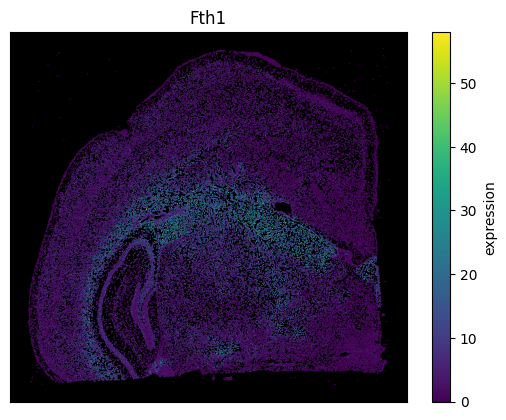

In [14]:
fig,ax=plt.subplots(dpi=100)
scatter=ax.scatter(x_sorted,y_sorted,c=values_sorted,cmap="viridis",s=0.75,linewidths=0)
fig.colorbar(scatter, ax=ax, label='expression')
ax.invert_yaxis()

#we color the background black to appreciate the viridis scale easily
ax.set_facecolor("black")
ax.set_xticklabels([])
ax.set_yticklabels([])
ax.set_xticks([])
ax.set_yticks([])
plt.title(gene)
plt.show()


The SpatialData way is as follows, but we don't guarantee it:

In [ ]:
%%time
plt.figure(figsize=(10, 10))
ax = plt.gca()

spatialdata_vhd_mb.pl.render_shapes("Visium_HD_3prime_Mouse_Brain_cell_segmentations", color=gene).pl.show(
    coordinate_systems="Visium_HD_3prime_Mouse_Brain_downscaled_hires", ax=ax
)

# almost 3 minutes!

## What we've learned so far

We can use SpatialData to load from many modalities. We can use visium_hd to point to where our data is and it will know its shapes, points, expression etc.

Using the tables and coordinates we can plot the expression of any gene.

### Illustration of Visium HD data


<table style="width:65%; background-color:#ffffff; color:#000000">
    <tr>
        <td width="30%"><img src="./assets/rect1.png">
        </td>
        <td width="70%">The <span style="background-color: #502754ff;color:#ffffff">purple</span> and <span style="background-color: #de7cc6ff">pink</span> pixels represent the histology, the  illustration shows an example of a nucleus. In this case, every pixel covers a 2µm bin. Every bin and pixel has an (<span style="background-color: #ff0000ff">x</span>,<span style="background-color: #008000ff">y</span>) coordinate so we know where it is located in space and we know who its neighbors are.
        </td>
    </tr>
    <tr>
        <td width="30%"><img src="./assets/rect2.png">
        </td>
        <td width="70%">
            <p>Every cube colored in a <span style="background-color: #440154ff; color:#ffffff">v</span><span style="background-color: #414487ff; color:#ffffff">i</span><span style="background-color: #414487ff; color:#ffffff">r</span><span style="background-color: #2a788eff; color:#ffffff">i</span><span style="background-color: #22a884ff; color:#ffffff">d</span><span style="background-color: #7ad151ff; color:#000000">i</span><span style="background-color: #fbfd25ff; color:#000000">s</span> scale represents the log(norm) expression of a gene. There are 18k+ gene expression values per 2µm bin.</p> 
            <p>A <span style="background-color: #00ff00ff">green</span> polygon shows what an annotation delineates as a nucleus. Without this polygon we would not know the extent of the nucleus. It can be selected by a human expert observer or automatically via segmentation algorithms. They are stored either as polygons (geometry) or labels (pixel-like).</p>
        </td>
    </tr>
    <tr>
        <td width="30%"><img src="./assets/rect3.png">
        </td>
        <td width="70%"> The polygon can also be converted into a label, illustrated here as <span style="background-color: #cb5d2bff">orange</span> and <span style="background-color: #3671d7ff">blue</span>. Both Polygons and Labels can be stored. Both humans and algorithms can draw polygons or paint pixels.
        </td>
    </tr>
    <tr>
        <td width="30%"><img src="./assets/rect4.png">
        </td>
        <td width="70%">
            <p>The expression accumulated within a label is what goes further into data analysis. </p>
            <p>Individual expression vectors can also go to analysis without being aggregated. However, since references are more on a single-cell level, individual vectors are more dificult to pair with it. When no reference is used then it is also called reference-free and segmentation-free analysis.</p>
        </td>
    </tr>
</table>


## What we will do

Now that we know where cells are, and how to access their expression, we will use SpatialData and Scanpy to do the analysis and give an identity to the cells based on their gene expression

---

# Part 3

## Preprocessing data

Get expression per cell (not bin), stored in tables.

`adata` is a reference to the existing table, it is not a copy, so any changes made to the adata will affect also the SpatialData object

We obtain this reference because Scanpy works with anndata not with SpatialData objects.

In [15]:
adata = spatialdata_vhd_mb.tables["cell_segmentations"]

In [16]:
#we will process X so let's keep a copy of the ra data as a layer
adata.layers["raw"]=adata.X.copy()

In [17]:
adata

AnnData object with n_obs × n_vars = 84031 × 33696
    obs: 'cell_id', 'region', 'cx', 'cy'
    var: 'gene_ids', 'feature_types', 'genome'
    uns: 'spatialdata_attrs'
    layers: None (.X), 'raw'

We print the summary output of what adata contains, to compare what variables are added after QC.

## Quality control

We calculate QC metrics and filter cells and genes

In [18]:
# 1. Quality Control: Filter out low-quality cells or artifacts
sc.pp.calculate_qc_metrics(adata, percent_top=None, inplace=True)


In [19]:
adata

AnnData object with n_obs × n_vars = 84031 × 33696
    obs: 'cell_id', 'region', 'cx', 'cy', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts'
    var: 'gene_ids', 'feature_types', 'genome', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts'
    uns: 'spatialdata_attrs'
    layers: None (.X), 'raw'

### Compute and plot cell area 

We have to do it manually because Scanpy does not offer it

In [20]:
areas = np.array([
    row["geometry"].area for _,row in spatialdata_vhd_mb.shapes['Visium_HD_3prime_Mouse_Brain_cell_segmentations'].iterrows()
])

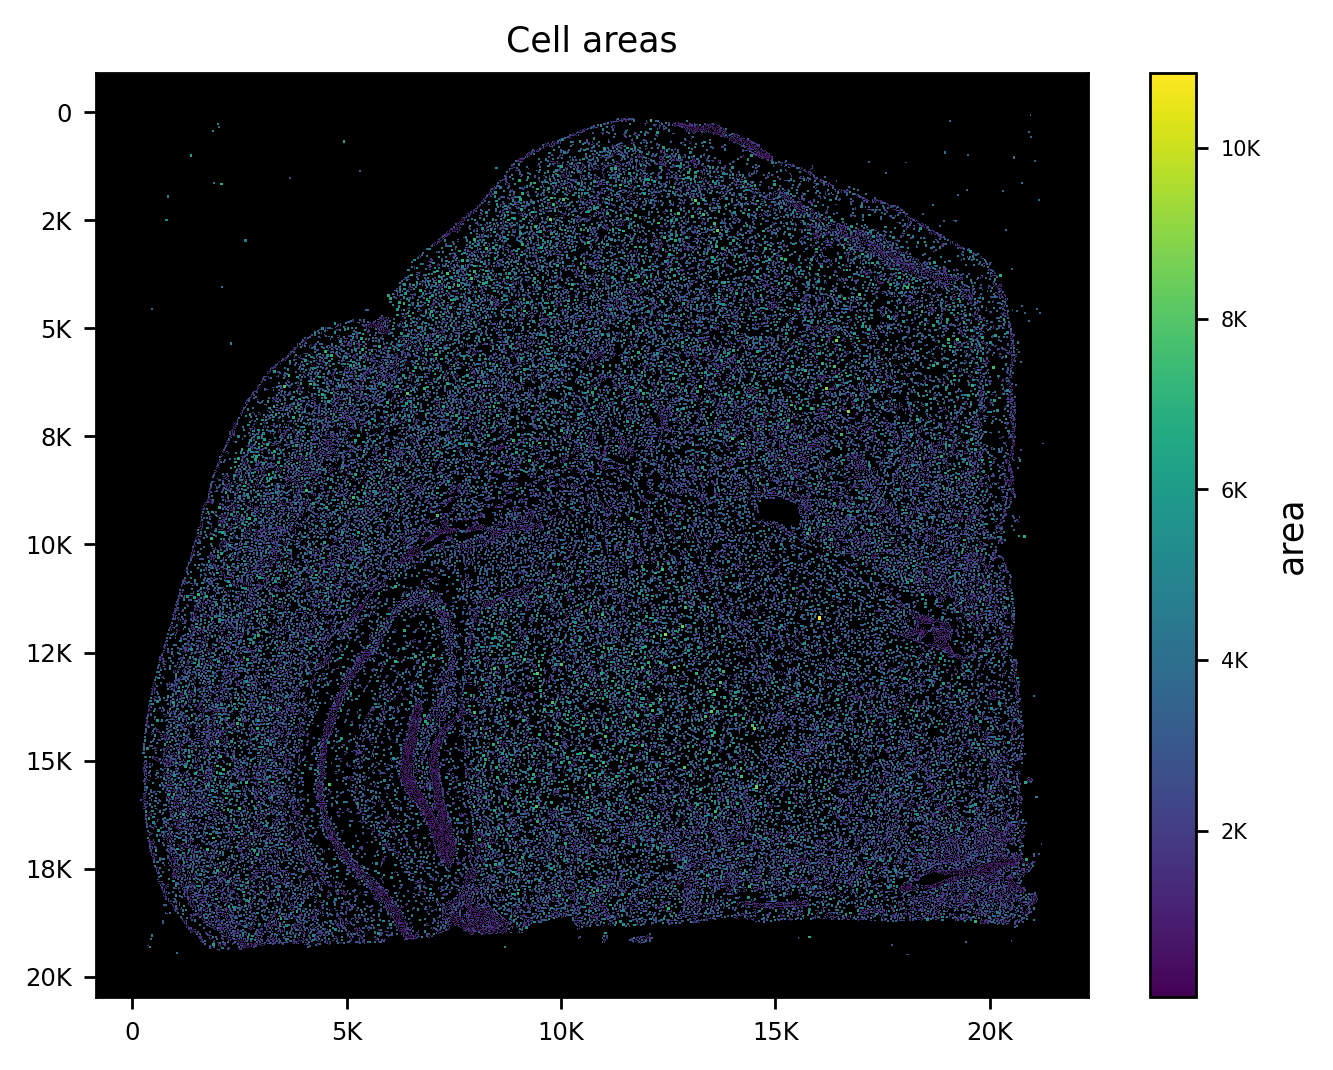

In [21]:
fig, ax=plt.subplots(dpi=250)
xs, ys = adata.obs["cx"].values.copy(),adata.obs["cy"].values.copy()
v=areas.copy()
sort_indices = np.argsort(v)
x_sorted, y_sorted, values_sorted = xs[sort_indices], ys[sort_indices], v[sort_indices]
sizes=values_sorted/values_sorted.max()

sp=ax.scatter(x_sorted, y_sorted, c=values_sorted,s=sizes,linewidths=0,marker=",")
ax.set_title("Cell areas", fontsize=10)    
ax.tick_params(axis='both', labelsize=7)
ax.xaxis.set_major_formatter(k_format)
ax.yaxis.set_major_formatter(k_format)
cbar=fig.colorbar(sp, ax=ax, label='area')
cbar.ax.yaxis.set_major_formatter(k_format)
cbar.ax.tick_params(labelsize=6)
ax.set_facecolor("black")
ax.invert_yaxis()

In [22]:
adata.var[['n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts']].describe()

,n_cells_by_counts,mean_counts,log1p_mean_counts,pct_dropout_by_counts,total_counts,log1p_total_counts
count,33696.000000,33696.000000,33696.000000,33696.000000,3.369600e+04,33696.000000
mean,1228.257835,0.019711,0.016443,98.538328,1.656322e+03,3.502675
std,3812.433759,0.152131,0.063231,4.536937,1.278373e+04,3.346273
min,0.000000,0.000000,0.000000,2.572860,0.000000e+00,0.000000
25%,0.000000,0.000000,0.000000,98.981031,0.000000e+00,0.000000
50%,15.000000,0.000179,0.000178,99.982149,1.500000e+01,2.772589
75%,856.250000,0.010437,0.010383,100.000000,8.770000e+02,6.777647
max,81869.000000,15.210625,2.785667,100.000000,1.278164e+06,14.060936


In [23]:
adata.obs[['n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts']].describe()

,n_genes_by_counts,log1p_n_genes_by_counts,total_counts,log1p_total_counts
count,84031.000000,84031.000000,84031.000000,84031.000000
mean,492.525092,5.954967,664.176819,6.202819
std,335.250747,0.761205,519.341125,0.830462
min,1.000000,0.693147,1.000000,0.693147
25%,248.000000,5.517453,305.000000,5.723585
50%,411.000000,6.021023,524.000000,6.263398
75%,657.000000,6.489205,870.000000,6.769642
max,2563.000000,7.849324,5667.000000,8.642591


### Plot QC metrics per observations spatially

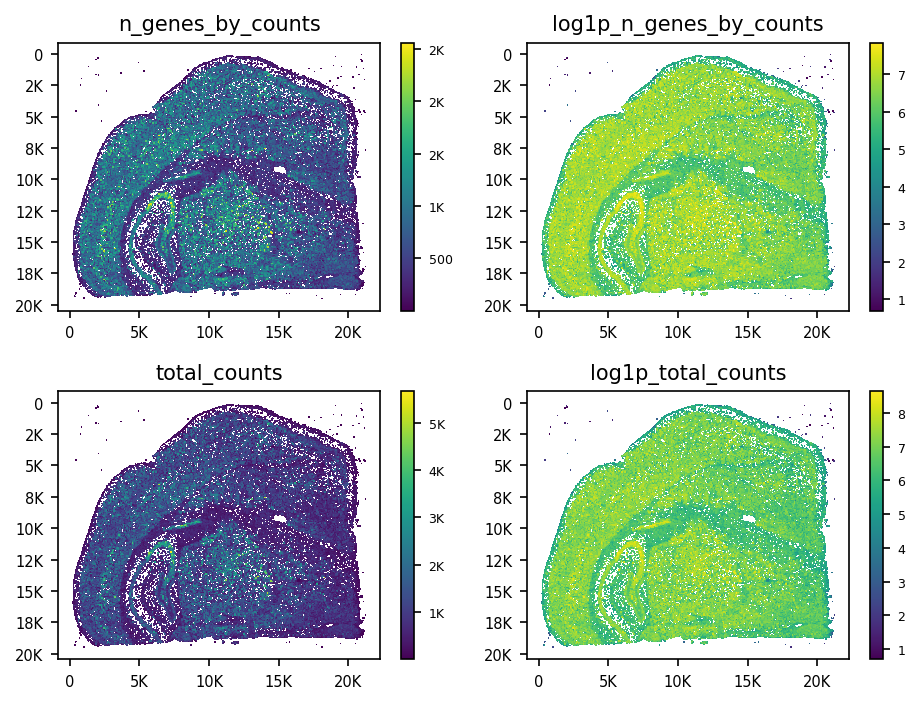

In [24]:
fig,axs=plt.subplots(2,2,dpi=150)
axs=axs.flatten()

for ax,c in zip(axs,['n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts']):
    xs, ys = adata.obs["cx"].values.copy(),adata.obs["cy"].values.copy()
    v=adata.obs[c].values.copy()
    sort_indices = np.argsort(v)
    x_sorted, y_sorted, values_sorted = xs[sort_indices], ys[sort_indices], v[sort_indices]
    sp=ax.scatter(x_sorted, y_sorted, c=values_sorted ,s=0.5,linewidths=0,marker=",")
    ax.set_title(c, fontsize=10)    
    ax.tick_params(axis='both', labelsize=7)
    ax.xaxis.set_major_formatter(k_format)
    ax.yaxis.set_major_formatter(k_format)
    ax.invert_yaxis()
    cbar = fig.colorbar(sp, ax=ax)
    cbar.ax.yaxis.set_major_formatter(k_format)
    cbar.ax.tick_params(labelsize=6)
plt.tight_layout()
plt.show()

Or explore them as a 1D plot

In [ ]:
#add here the columns you'd like to see
for c in ['log1p_total_counts']:#,'log1p_mean_counts']:
    fig,axs=plt.subplots(1,2,figsize=(7,2))
    sns.violinplot(adata.var,x=c,orient="h",ax=axs[1])
    sns.histplot(adata.var['log1p_total_counts'],bins=100,ax=axs[0])
    plt.show()

## Now we filter data by cells and by genes

In [25]:
sc.pp.filter_cells(adata, min_genes=100)
sc.pp.filter_genes(adata, min_cells=3)

In [26]:
adata

AnnData object with n_obs × n_vars = 79868 × 19876
    obs: 'cell_id', 'region', 'cx', 'cy', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'n_genes'
    var: 'gene_ids', 'feature_types', 'genome', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells'
    uns: 'spatialdata_attrs'
    layers: None (.X), 'raw'

Notice we now have data of size 79868 × 19876, instead of the original 84031 × 33696. We dropped 4163 cells because they contained almost no gene expression. And we dropped 13820 genes because they were expressed in very few cells (if any)

## Transformations

We transform the data into counts per ten-thousands and to a log transform

In [27]:
# 2. Normalization and Log-Transformation
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)

## Use Scanpy to detect highly variable genes

Don't be afraid to change parameters

In [28]:
# 3. Identify Highly Variable Genes & Scale
sc.pp.highly_variable_genes(adata, min_mean=0.0125, max_mean=3, min_disp=0.5,
    subset=False)
adata = adata[:, adata.var.highly_variable]
sc.pp.scale(adata, max_value=10)


Let's see how adata looks now

In [29]:
adata

AnnData object with n_obs × n_vars = 79868 × 2978
    obs: 'cell_id', 'region', 'cx', 'cy', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'n_genes'
    var: 'gene_ids', 'feature_types', 'genome', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: 'spatialdata_attrs', 'log1p', 'hvg'
    layers: None (.X), 'raw'

## Results of preprocessing

Notice that the table `adata` now has many more values in the `obs` and `var` tables.

- `obs` started with :

&emsp;&emsp;&emsp; ['cell_id', 'region']

&emsp;&emsp;&emsp; and now it has 

&emsp;&emsp;&emsp; ['cell_id', 'region', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'n_genes']


- `var` started with :

&emsp;&emsp;&emsp; ['gene_ids', 'feature_types', 'genome']

&emsp;&emsp;&emsp; and now it has 

&emsp;&emsp;&emsp; ['gene_ids', 'feature_types', 'genome', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std']


- The original size was

&emsp;&emsp;&emsp; `84031 x 33696`

&emsp;&emsp;&emsp; and now it is

&emsp;&emsp;&emsp; `79868 × 2978`

meaning cells and genes have been filtered and we now have 2978 out of 33696 genes! and we have removed 4163 cells

These changes are computed via Scanpy doing quality control, transforming and selecting HVGs.

## What we've learned

We are now masters of SpatialData. We understand that the expression is within tables and the .X inside. 

After getting the expression we do quality control and filter cells and genes.

We find highly variable genes

This proces changes the SpatialData object and the anndata tables inside, adds new data that is expected by Scanpy and removes genes and cells that have little varibility.

---

# Part 4

## Analysis per cell

## Dimensionality reduction

In order to find expression patterns and find celltypes, we need to reduce and transform data a bit further. We need to reduce dimensionality. A common way to do this is with PCA. We reduce from 2978 genes to `n_pcs` (30) amount of principal components.

This means that at this point we have cells that have 2978 genes, but since we can't see in 2978 dimensions we go down to 30.

However, since we can't see in 30 dimensions, we use UMAP to visualize in 2D the different groups that could potentially correspond to unique expression patterns.

In [30]:
# Run PCA, Neighborhood graph embedding, and UMAP
sc.tl.pca(adata, svd_solver='arpack')
sc.pp.neighbors(adata, n_neighbors=20, n_pcs=30)
sc.tl.umap(adata)

We can plot the umap in two ways:

In [ ]:
sc.pl.umap(adata)

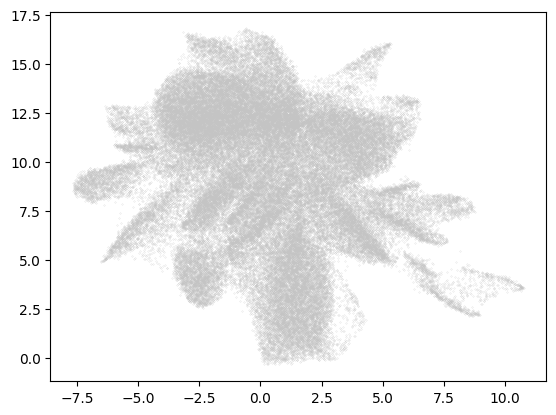

In [31]:
plt.scatter(adata.obsm['X_umap'][...,0],adata.obsm['X_umap'][...,1],marker=".",s=0.1,c="#c4c4c4")

We can already observe that there are groups, but which ones? We will discover it with **clustering**.

## Leiden clustering

Leiden clustering is a type of clustering called **graph partitioning**. It is important to note that in order to use Leiden we need a **graph**! 

Once we have our data reduced to `n_pcs`, Scanpy uses scikit-learn and other python libraries to compare each cell with the `n_pcs`s to other cells. If one cell's `n_pcs` are similar to another cell's `n_pcs` , then an edge is created. If the `n_pcs` of a cell are different to another cell then no edge is created.

The Scanpy funciton `sc.tl.leiden` takes our `adata` which contains the PCA results, creates a graph, runs a graph partitioning algorithm and stores such partitioning in the colum of `cell_clusters`

In [32]:
# Cluster the single cells using Leiden or Louvain algorithm
sc.tl.leiden(adata, resolution=2.7, key_added="cell_clusters")

make sure clusters are integers and not strings

In [38]:
adata.obs["cell_clusters"]=adata.obs["cell_clusters"].astype(int)

How many unique clusters do we get?

In [39]:
len(np.unique(adata.obs["cell_clusters"]))

34

Visualize the clusters using the 2D UMAP 

... storing 'feature_types' as categorical
... storing 'genome' as categorical


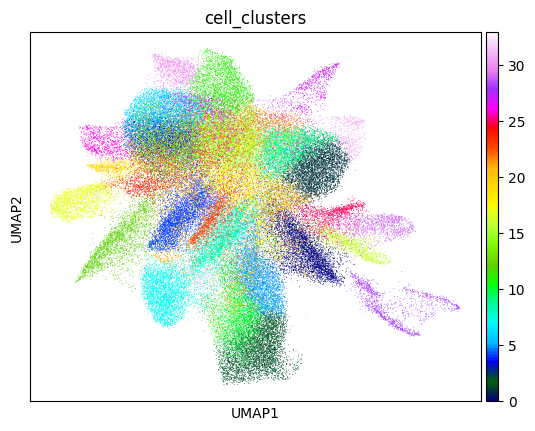

In [35]:
sc.pl.umap(adata, color="cell_clusters",cmap="gist_ncar")

once more we will plot by quickly looking at the geometries of cells 

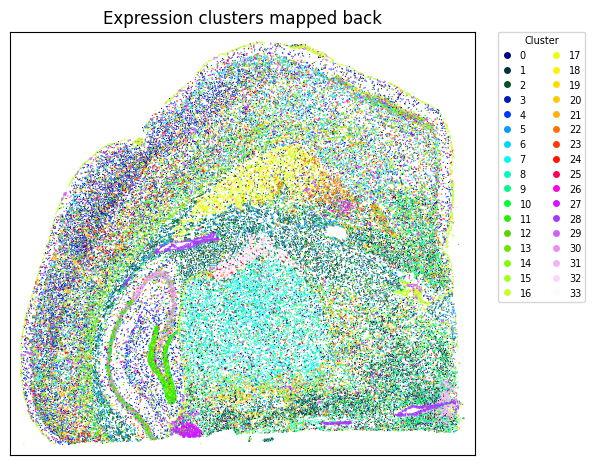

In [40]:
fig, ax = plt.subplots(dpi=100,figsize=(6,5.5))

scatter = ax.scatter(
    adata.obs["cx"],adata.obs["cy"], #x y of cells
    c=adata.obs["cell_clusters"], #color by clusters
    s=0.75, #small dots
    cmap="gist_ncar",#"gist_ncar", #colormaps ready for many clusters, more than 20 colors
    linewidths=0, #no lines in the points
)

# <optional> This code is optional! ---------------- ⌄

#    Create legend with unique cluster labels
handles, _ = scatter.legend_elements(num=None)
legend = ax.legend(
    handles,
    sorted(np.unique(adata.obs["cell_clusters"])),
    bbox_to_anchor=(1.05, 1),
    borderaxespad=0.,
    fontsize=7,
    handlelength=1.0,
    handleheight=0.8,
    labelspacing=0.5,
    title="Cluster",
    loc="upper left",
    ncol=2,
    title_fontsize=7
)


#   Adjust legend marker size
for handle in legend.legend_handles:
    handle.set_markersize(5.0)


# </optional> code above is optional! --------------- ^

ax.set_xticklabels([]);ax.set_yticklabels([])
ax.set_xticks([]);ax.set_yticks([])

ax.set_xlim((adata.obs["cx"].min()-500,adata.obs["cx"].max()+500))
ax.set_ylim((adata.obs["cy"].min()-500,adata.obs["cy"].max()+500))

ax.invert_yaxis()

plt.title("Expression clusters mapped back")
plt.show()

### Checkpoint

If you want, write the spatial data object so that we don't need to run all of this again

In [35]:
path_write2=path_read + "dataProcessed.zarr"
path_read="/home/leslie/Documents/NBIS/dataforpractical4/"

In [ ]:
spatialdata_vhd_mb.tables["cell_segmentations"]=adata
spatialdata_vhd_mb.write(path_write2,overwrite=True)

### Come back to this checkpoint 

if you wish to continue from here.

In [ ]:
#spatialdata_vhd_mb = sd.read_zarr(path_write2)
#adata=spatialdata_vhd_mb.tables["cell_segmentations"]

In [41]:
spatialdata_vhd_mb.tables["cell_segmentations"]

AnnData object with n_obs × n_vars = 79868 × 19876
    obs: 'cell_id', 'region', 'cx', 'cy', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'n_genes'
    var: 'gene_ids', 'feature_types', 'genome', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'spatialdata_attrs', 'log1p', 'hvg'
    layers: None (.X), 'raw'

## Where are the images? Where is the histology?

So far we have seen nice scatterplots but how does the histology look like?

We don't always get access to the full resolution WSI. But from Spaceranger we get a decent high resolution downsampled version of approximately 6000 pixels.

We will look at it and then plot our findings on top.

We know that the SpatialData object has the **images**, the actual pixels

<img style="width:50%" src="./assets/imagesoutput.jpg"/>

scales 3.552999922189302 3.552999922189302


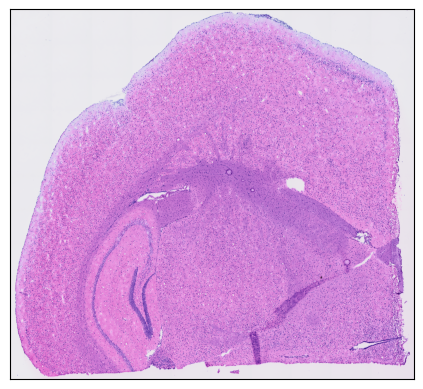

In [42]:
# get the downsample factor for the hires image. Found within attrs (attributes) within the SpatialData Object
scale=spatialdata_vhd_mb["Visium_HD_3prime_Mouse_Brain_hires_image"].attrs['transform']['Visium_HD_3prime_Mouse_Brain'].scale
scaley,scalex = scale[-2],scale[-1]
print("scales",scaley,scalex)

# get the actual pixels
img = np.transpose(spatialdata_vhd_mb["Visium_HD_3prime_Mouse_Brain_hires_image"].values.copy(), (1, 2, 0))

#draw
fig, ax = plt.subplots(dpi=100)
ax.imshow(img)
ax.set_xticklabels([])
ax.set_yticklabels([])
ax.set_xticks([])
ax.set_yticks([])
plt.show()

## Let's plot our clusters on top of the image


We can look at the Hypothalamus

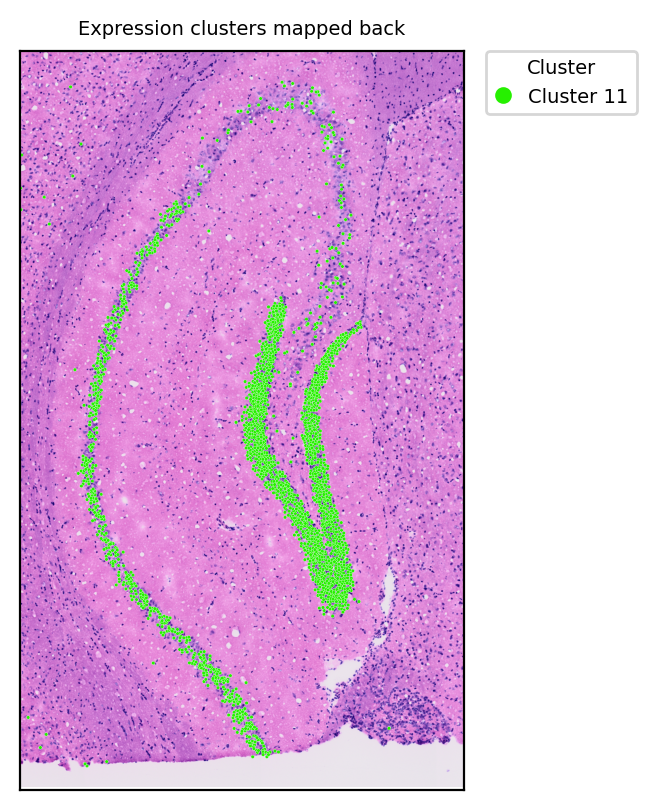

In [43]:
fig, ax = plt.subplots(dpi=200)
ax.imshow(img)

# change here if you want to see other clusters----
cluster_subset=[11]
uc=len(np.unique(adata.obs["cell_clusters"]))
cmap = matplotlib.colormaps["gist_ncar"].resampled(uc)

# Create a colormap dictionary for your clusters
colormap = {cluster: cmap(i) for i, cluster in enumerate(range(uc))}

subset=adata.obs[adata.obs["cell_clusters"].isin(cluster_subset)]

scatter = ax.scatter(
    subset["cx"]/scalex, subset["cy"]/scaley, #x y of cells
    c=subset["cell_clusters"].map(colormap).values, #color by clusters
    marker="o",
    s=1.5, #small dots
    cmap="magma_r",
    linewidths=0.1, #no lines in the points
    edgecolors="white"
)

ax.set_xlim(1000,2500);ax.set_ylim(3000,5500)

ax.set_xticklabels([]);ax.set_yticklabels([])

ax.set_xticks([]);ax.set_yticks([])

ax.invert_yaxis()

legend_handles = []
for cluster_id in cluster_subset:
    color=colormap[cluster_id]
    legend_handles.append(
        mlines.Line2D(  [],[],color=color,marker="o",linestyle="None",markersize=5.0,label=f"Cluster {cluster_id}")
    )
# Add the legend manually
legend = ax.legend(
    handles=legend_handles,bbox_to_anchor=(1.05, 1),borderaxespad=0.,fontsize=7,handlelength=1.0,
    handleheight=0.8,labelspacing=0.5,title="Cluster",loc="upper left",ncol=1,title_fontsize=7
)

# Adjust legend marker size (if needed)
for handle in legend.legend_handles:
    handle.set_markersize(5.0)

plt.title("Expression clusters mapped back", fontsize=7)
plt.show()


## What we learned

We used **PCA** via Scanpy to do dimensionaliy reduction.

We use **LeidenAlg** via Scanpy to take the reduced data to create a graph and then partitions it into clusters

We map the clusters to the locations of the cells

We observed the histology underneath the data and found it within SpatialData

---



# Part 5

We have clusters, great, but what are the cell types?

We need two main things.
1. First we need to know which genes are the most representative of each cluster.
2. We need a reference, a.k.a atlas, single-cell reference

To do 1. and know the representative genes per cluster we do **differential gene expression (DEG)**. To do this we do a series of statistical tests to see if the accumulated expression in a gene in a cluster is different from the other clusters.

To do 2. We need a reference. There are multiple ones availabel for brain tissue. We will use [CellTypist](https://www.celltypist.org/). They have a set of models that take gene expression and they return the cell types that seem more likely.

## Differential gene expression

With `sc.tl.rank_genes_groups` we can perform several different types of statistical tests to estimate which genes are more representative of these clusters. 

This is one way to look into genes per leiden cluster. But if we want the cell type we can search manually or have domain knowledge. But if we don't, we can use libraries like CellTypist.

In [ ]:
adata.obs["cell_clusters"]=adata.obs["cell_clusters"].astype(str)
sc.tl.rank_genes_groups(
    adata,
    groupby="cell_clusters",  # Your cluster column
    method="wilcoxon",  # or "t-test_overestim_var"
    key_added="cluster_markers",
    n_genes=90,  # Top 90 markers per cluster
)

# Extract top markers for each cluster
top_markers = pd.DataFrame(adata.uns["cluster_markers"]["names"]).head(90)


In [45]:
top_markers

,0,1,2,3,4,5,6,7,8,9,...,24,25,26,27,28,29,30,31,32,33
0,Itm2a,Nap1l5,Mobp,Ppp3ca,Slc1a3,Mobp,Cck,Prkcd,Agt,6330403K07Rik,...,Pvalb,Vtn,Gad1,Nwd2,Dbi,Acta2,Hpca,Resp18,Pvalb,Sirt2
1,Bsg,Resp18,Mal,Cck,Htra1,Mal,Ccn3,Pcp4,Sparc,Ly6h,...,Gad1,Rgs5,Cnr1,Tac2,Nnat,Tagln,Ppp3ca,Ly6h,Gad1,Cnp
2,Cldn5,6330403K07Rik,Trf,Camk2a,Slc1a2,Qdpr,Ly6h,Cck,Ndrg2,Resp18,...,Slc6a1,Atp1a2,Gad2,Gng14,Ttr,Mgp,Cck,6330403K07Rik,Kif5a,Mpzl1
3,Ly6c1,Ly6h,Dbndd2,Hpca,Mfge8,Dbndd2,Ppp3ca,Zic1,Atp1a2,Nap1l5,...,Nap1l5,Igfbp7,Slc6a1,Sncg,Rarres2,Myl9,Cabp7,Cartpt,Mobp,Nfasc
4,Slc2a1,Scg2,Cldn11,Id2,Atp1a2,Plekhb1,Camk2a,Ndrg2,Slc6a11,Scg2,...,Gad2,Sparc,Npy,Gng8,Pltp,Apod,Camk2a,Npy,Sst,Marcks
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
85,Slc30a1,Ctsd,Gltp,Dazap2,Il18,Litaf,Ski,Etfa,Mdk,Prlh,...,Mob2,Ano1,Ablim1,Asb2,Drc3,Fbln5,Hnrnpm,H2-D1,Serpinf1,Josd2
86,Ctsh,Tspan6,Gjc3,Gstm5,Timp4,Map4k4,Pccb,Pabpc1,Gpld1,Calca,...,M6pr,Ace2,Sulf2,Wfdc1,Rnase4,Tgm2,Cdc42se1,Trh,Golga7,Efcab14
87,Ablim1,Zdhhc20,Map7,Slc20a1,Ptn,Trim59,Igfbp4,Abhd3,Gstm5,Spsb2,...,Pgd,Gper1,Tvp23b,Trpm3,Sox9,Tagln2,Ctsd,Stat3,Laptm4a,Card19
88,Srarp,Nkain4,Rnf130,Ppib,Mertk,Pde8a,Ybx1,Ntsr2,Paqr6,Tent5a,...,Wsb1,Il34,Errfi1,Rnh1,Serpinh1,Laptm4a,Ostf1,Snhg20,Pllp,Slc12a2


## Celltypist

Developed by the Sanger Institute, CellTypist is an automated Python tool that uses logistic regression optimized with Stochastic Gradient Descent (SGD) to rapidly identify and annotate cell types in single-cell RNA sequencing data. It features extensive pre-trained reference models while allowing users to easily train and deploy their own custom classifiers.

The paper is [here](https://doi.org/10.1016/j.cell.2023.11.026)

We need to download the model manually from [https://celltypist.cog.sanger.ac.uk/models/Adult_MouseBrain_Yao/v1/Mouse_Whole_Brain.pkl](https://celltypist.cog.sanger.ac.uk/models/Adult_MouseBrain_Yao/v1/Mouse_Whole_Brain.pkl) (working as of Aug 2026)

Otherwise look into the [main model list](https://www.celltypist.org/models) for the "Mouse_Whole_Brain"







In [ ]:
model_path="./celltypist_models/Mouse_Whole_Brain.pkl"
model = celltypist.models.Model.load(model_path)
model

CellTypist model with 334 cell types and 5596 features
    date: 2024-04-30 17:19:37.721313
    details: cell types from the whole adult mouse brain
    source: https://doi.org/10.1038/s41586-023-06812-z
    version: v1
    cell types: 001 CLA-EPd-CTX Car3 Glut, 002 IT EP-CLA Glut, ..., 338 Lymphoid NN
    features: Xkr4, Rgs20, ..., mt-Cytb

we will store the transformed data we had been using so far and take the raw counts for celltypist

In [ ]:
adata.layers["log_transformed"]=adata.X.copy()
adata.X=adata.layers["raw"].copy()

In [49]:
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)

Now Celltypist does its job

In [50]:
predictions = celltypist.annotate(
    adata,
    model=model,
    mode='best match',
    majority_voting=True  # Recommended for better accuracy
)

🔬 Input data has 79868 cells and 2978 genes
🔗 Matching reference genes in the model
🧬 1421 features used for prediction
⚖️ Scaling input data
🖋️ Predicting labels
✅ Prediction done!
👀 Detected a neighborhood graph in the input object, will run over-clustering on the basis of it
⛓️ Over-clustering input data with resolution set to 20
🗳️ Majority voting the predictions
✅ Majority voting done!


We get the majority voting of CellTypist and save it in out anndata

In [51]:
adata.obs['celltypist_cell_type']=predictions.predicted_labels['majority_voting']


Which celltypes did we get?

In [52]:
ct_celltypes,counts=np.unique(adata.obs['celltypist_cell_type'],return_counts=True)
#sort them by counts:
sortedid=np.argsort(counts)
reversed_arr = sortedid[::-1]
ct_celltypes=ct_celltypes[reversed_arr]
counts=counts[reversed_arr]

countdict={ct_celltypes[i]:counts[i] for i in range(len(ct_celltypes))}

countdict

{'319 Astro-TE NN': np.int64(18500),
 '327 Oligo NN': np.int64(11566),
 '151 TH Prkcd Grin2c Glut': np.int64(9759),
 '318 Astro-NT NN': np.int64(9606),
 '107 DMH Hmx2 Gaba': np.int64(6078),
 '333 Endo NN': np.int64(2570),
 '053 Sst Gaba': np.int64(2390),
 '062 STR D2 Gaba': np.int64(2123),
 '047 Sncg Gaba': np.int64(1742),
 '330 VLMC NN': np.int64(1674),
 '326 OPC NN': np.int64(1573),
 '007 L2/3 IT CTX Glut': np.int64(1398),
 '063 STR D1 Sema5a Gaba': np.int64(1243),
 '004 L6 IT CTX Glut': np.int64(1088),
 '119 SI-MA-LPO-LHA Skor1 Glut': np.int64(815),
 '006 L4/5 IT CTX Glut': np.int64(807),
 '029 L6b CTX Glut': np.int64(669),
 '165 PAG-MRN Pou3f1 Glut': np.int64(577),
 '010 IT AON-TT-DP Glut': np.int64(556),
 '323 Ependymal NN': np.int64(528),
 '093 RT-ZI Gnb3 Gaba': np.int64(478),
 '171 PAG Pou4f1 Bnc2 Glut': np.int64(463),
 '049 Lamp5 Gaba': np.int64(451),
 '329 ABC NN': np.int64(414),
 '322 Tanycyte NN': np.int64(383),
 '325 CHOR NN': np.int64(354),
 '046 Vip Gaba': np.int64(339),


We got an interesting set, next we will see the regions they belong to

In [53]:
regions={}

for i in range(len(ct_celltypes)):
    celltype=ct_celltypes[i]
    amount=int(counts[i])
    # Extract region from celltype name
    if 'CTX' in celltype:
        region = 'Cortex'
    elif 'AON' in celltype or 'OB' in celltype:
        region = 'Olfactory System'
    elif 'STR' in celltype:
        region = 'Striatum'
    elif 'Gaba' in celltype and ('Vip' in celltype or 'Sncg' in celltype or 'Lamp5' in celltype or 'Pvalb' in celltype or 'Sst' in celltype):
        region = 'Cortical Interneurons'
    elif 'CEA-BST' in celltype:
        region = 'Amygdala/Basal Forebrain'
    elif 'TU-ARH' in celltype or 'DMH' in celltype or 'LPO-LHA' in celltype:
        region = 'Hypothalamus'
    elif 'RT-ZI' in celltype or 'ZI' in celltype or 'TH' in celltype:
        region = 'Thalamus/Zona Incerta'
    elif 'MH' in celltype or 'PAG' in celltype:
        region = 'Midbrain'
    elif 'NN' in celltype:
        region = 'Non-Neuronal Cells'
    else:
        region = 'Other'

    if region in regions:
        regions[region].append(celltype)
    else:
        regions[region]=[celltype]

ctoregion={}
for r, celltypes in regions.items():
    for c in celltypes:
        ctoregion[c] = r


In [55]:
print(ctoregion)
print(regions)

{'319 Astro-TE NN': 'Non-Neuronal Cells', '327 Oligo NN': 'Non-Neuronal Cells', '318 Astro-NT NN': 'Non-Neuronal Cells', '333 Endo NN': 'Non-Neuronal Cells', '330 VLMC NN': 'Non-Neuronal Cells', '326 OPC NN': 'Non-Neuronal Cells', '323 Ependymal NN': 'Non-Neuronal Cells', '329 ABC NN': 'Non-Neuronal Cells', '322 Tanycyte NN': 'Non-Neuronal Cells', '325 CHOR NN': 'Non-Neuronal Cells', '321 Astroependymal NN': 'Non-Neuronal Cells', '151 TH Prkcd Grin2c Glut': 'Thalamus/Zona Incerta', '093 RT-ZI Gnb3 Gaba': 'Thalamus/Zona Incerta', '109 LGv-ZI Otx2 Gaba': 'Thalamus/Zona Incerta', '101 ZI Pax6 Gaba': 'Thalamus/Zona Incerta', '107 DMH Hmx2 Gaba': 'Hypothalamus', '119 SI-MA-LPO-LHA Skor1 Glut': 'Hypothalamus', '104 TU-ARH Otp Six6 Gaba': 'Hypothalamus', '053 Sst Gaba': 'Cortical Interneurons', '047 Sncg Gaba': 'Cortical Interneurons', '049 Lamp5 Gaba': 'Cortical Interneurons', '046 Vip Gaba': 'Cortical Interneurons', '052 Pvalb Gaba': 'Cortical Interneurons', '062 STR D2 Gaba': 'Striatum', '

We have prepared a colormap specifically for these celltypes

In [56]:
celltype_colors={"049 Lamp5 Gaba":"#ff6f1f", "007 L2/3 IT CTX Glut":"#dc8add", "151 TH Prkcd Grin2c Glut":"#80407c", "119 SI-MA-LPO-LHA Skor1 Glut":"#13e768", "330 VLMC NN":"#7376aa", "319 Astro-TE NN":"#9e8e83", "047 Sncg Gaba":"#893100", "329 ABC NN":"#f8e45c", "333 Endo NN":"#a6abf5", "327 Oligo NN":"#d8bcd4", "107 DMH Hmx2 Gaba":"#269a56", "326 OPC NN":"#ffc5e2", "053 Sst Gaba":"#ffbe6f", "004 L6 IT CTX Glut":"#c061cb", "029 L6b CTX Glut":"#452c59", "052 Pvalb Gaba":"#c64600", "062 STR D2 Gaba":"#ff0000", "010 IT AON-TT-DP Glut":"#73ff00", "061 STR D1 Gaba":"#bf3037", "046 Vip Gaba":"#e66100", "006 L4/5 IT CTX Glut":"#762a91", "101 ZI Pax6 Gaba":"#aa1ca2", "318 Astro-NT NN":"#62a0ea", "045 OB-STR-CTX Inh IMN":"#301e3e", "109 LGv-ZI Otx2 Gaba":"#95328f", "322 Tanycyte NN":"#e283e1", "165 PAG-MRN Pou3f1 Glut":"#bfb130", "063 STR D1 Sema5a Gaba":"#804043", "082 CEA-BST Ebf1 Pdyn Gaba":"#31e97d", "104 TU-ARH Otp Six6 Gaba":"#006329", "325 CHOR NN":"#9c6781", "323 Ependymal NN":"#e18ccd", "093 RT-ZI Gnb3 Gaba":"#bf00b5", "171 PAG Pou4f1 Bnc2 Glut":"#59542c", "321 Astroependymal NN":"#cda8e9", "145 MH Tac2 Glut":"#ffe600"} 

#if during the course of this tutorial a new cell appears we will color it gray
for ct in ct_celltypes:
    if ct not in celltype_colors:
        celltype_colors[ct]="#aaaaaa"
        print("cell type not in color dictionary",ct)

In [57]:
adata.obs['celltypist_color']=adata.obs['celltypist_cell_type'].map(celltype_colors)
adata.obs['celltypist_region']=adata.obs['celltypist_cell_type'].map(ctoregion)

get the **mode** of cell clusters

In [58]:
cttocluster = adata.obs.groupby(by="celltypist_cell_type").agg({"cell_clusters": lambda x: x.mode()[0]}).to_dict()["cell_clusters"]

### now let's make a really beautiful plot

of celltypes based on the Visium HD gene expression!

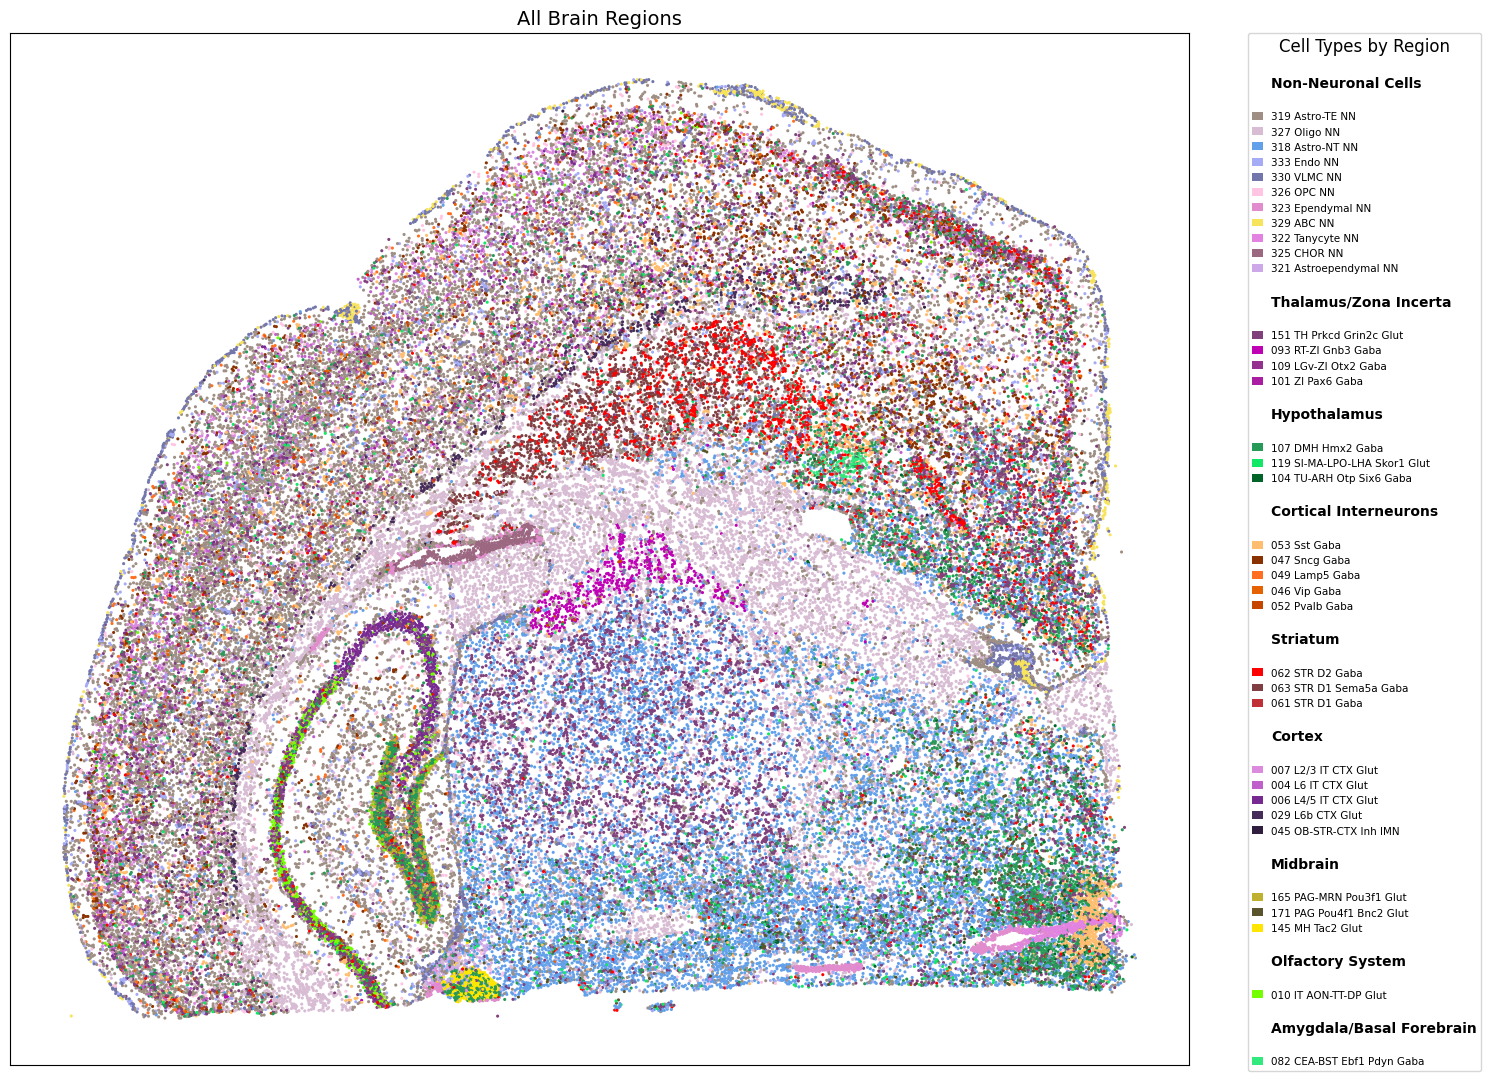

In [59]:
# Create figure
fig, ax = plt.subplots(dpi=100, figsize=(15, 12))

# Scatter plot with all cells
scatter = ax.scatter(
    adata.obs["cx"],
    adata.obs["cy"],
    c=adata.obs["celltypist_color"],
    s=5,
    linewidths=0,
)

# --- Create grouped legend ---
legend_elements = []

# Add elements for each region
for region, celltypes in regions.items():
    # Add region title (bold, no color)
    legend_elements.append(
        mpatches.Patch(facecolor='none', edgecolor='none',
                      label=f'\n{region}\n', linewidth=0)
    )

    # Add cell types in this region
    for celltype in celltypes:
        legend_elements.append(
            mpatches.Patch(facecolor=celltype_colors[celltype],
                          label=f'  {celltype}')
        )

# Create legend
legend = ax.legend(
    handles=legend_elements,
    bbox_to_anchor=(1.05, 1),
    loc='upper left',
    borderaxespad=0.,
    fontsize=7.5,
    title='Cell Types by Region',
    title_fontsize=12,
    handlelength=1.0,
    handleheight=0.8,
    ncol=1,
    labelspacing=0.5,
)

# Customize region title appearance
for text in legend.get_texts():
    if text.get_text().strip() in regions:  # If it's a region title
        text.set_fontweight('bold')
        text.set_fontsize(10)
    elif text.get_text().startswith('  '):  # If it's a cell type
        text.set_text(text.get_text()[2:])  # Remove indentation

ax.invert_yaxis()
ax.set_xticklabels([])
ax.set_yticklabels([])
ax.set_xticks([])
ax.set_yticks([])
plt.title("All Brain Regions", fontsize=14)
plt.tight_layout()
plt.show()

# How is everything related?

How do clusters and celltypes and UMAPs and PCA relate?

Let's look at the Leiden clusters we found, in their UMAP space, and the celltypes also in UMAP space side by side:

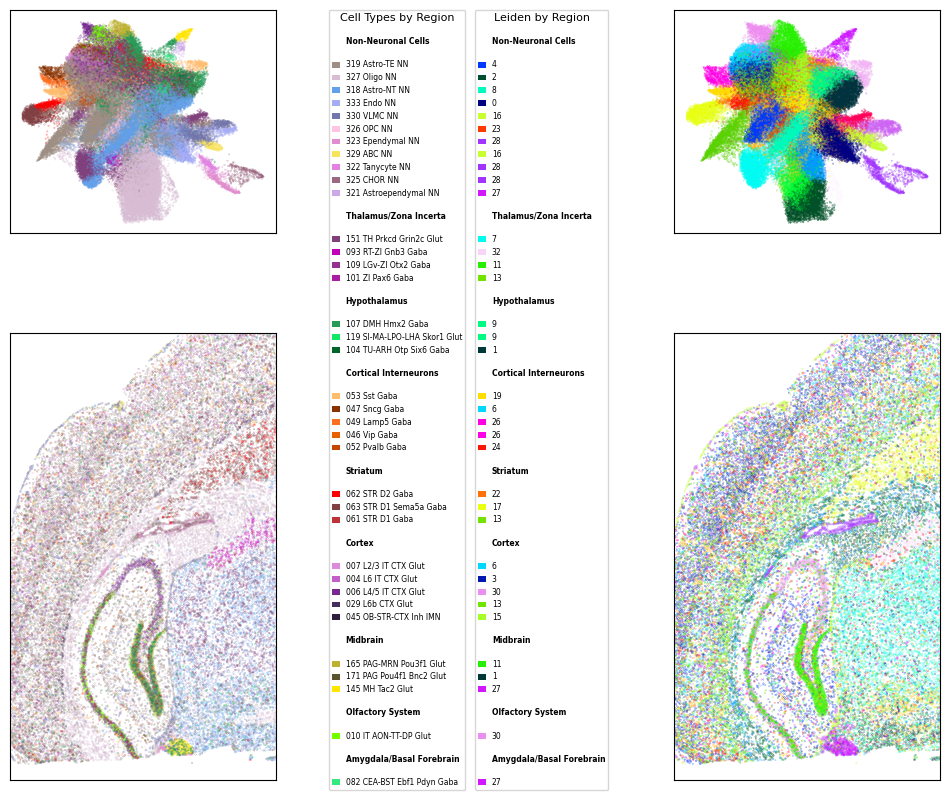

In [89]:
# Create figure with custom grid layout
fig = plt.figure(figsize=(12, 10), dpi=100)  # Adjust height as needed
gs = gridspec.GridSpec(2, 2, height_ratios=[1, 2])  # Bottom row twice as tall

# Create subplots with the grid
axs = [fig.add_subplot(gs[0, 0]),  # Top-left
       fig.add_subplot(gs[0, 1]),  # Top-right
       fig.add_subplot(gs[1, 0]),  # Bottom-left (taller)
       fig.add_subplot(gs[1, 1])]  # Bottom-right (taller)

# Remove ticks for all subplots
for ax in axs:
    ax.set_xticklabels([]); ax.set_yticklabels([])
    ax.set_xticks([]); ax.set_yticks([])

# Your plotting code
axs[0].scatter(adata.obsm['X_umap'][...,0], adata.obsm['X_umap'][...,1],
               marker=".", s=0.1, c=adata.obs["celltypist_color"].values)
axs[1].scatter(adata.obsm['X_umap'][...,0], adata.obsm['X_umap'][...,1],
               marker=".", s=0.1, c=adata.obs["cell_clusters"].values.astype(int),
               cmap="gist_ncar")
axs[2].scatter(adata.obs['cx'], adata.obs['cy'], marker=".", s=0.1,
               c=adata.obs["celltypist_color"].values)
axs[3].scatter(adata.obs['cx'], adata.obs['cy'], marker=".", s=0.1,
               c=adata.obs["cell_clusters"].values.astype(int), cmap="gist_ncar")

# Set limits
axs[2].set_ylim((20000, 2000))
axs[3].set_ylim((20000, 2000))
axs[2].set_xlim((1500, 12000))
axs[3].set_xlim((1500, 12000))

# legend code
legend_elements1 = []
legend_elements2 = []

for region, celltypes in regions.items():
    legend_elements1.append(mpatches.Patch(facecolor='none', edgecolor='none',
                                          label=f'\n{region}\n', linewidth=0))
    legend_elements2.append(mpatches.Patch(facecolor='none', edgecolor='none',
                                          label=f'\n{region}\n', linewidth=0))

    for celltype in celltypes:
        legend_elements1.append(mpatches.Patch(facecolor=celltype_colors[celltype],
                                             label=f'  {celltype}'))
        legend_elements2.append(mpatches.Patch(facecolor=colormap[int(cttocluster[celltype])],
                                             label=f'  {cttocluster[celltype]}'))

# Create legends
legend1 = axs[0].legend(
    handles=legend_elements1, bbox_to_anchor=(1.2, 1), loc='upper left',
    borderaxespad=0., fontsize=5.5, title='Cell Types by Region',
    title_fontsize=8, handlelength=1.0, handleheight=0.8, ncol=1,
    labelspacing=0.5)
legend2 = axs[1].legend(
    handles=legend_elements2, bbox_to_anchor=(-.75, 1), loc='upper left',
    borderaxespad=0., fontsize=5.5, title='Leiden by Region',
    title_fontsize=8, handlelength=1.0, handleheight=0.8, ncol=1,
    labelspacing=0.5)

# Customize legend appearance
for l in [legend1,legend2]:
    for text in l.get_texts():
        if text.get_text().strip() in regions:
            text.set_fontweight('bold')
        elif text.get_text().startswith('  '):
            text.set_text(text.get_text()[2:])


plt.subplots_adjust(wspace=1.5, hspace=0.3)  # Adjust hspace as needed
plt.show()

**Important**

CellTypist uses the Leiden graph we already created but it makes a new clustering, so we might find different amounts of Leiden clusters and CellTypist clusters (cell types), but we can match them, as in the figure above. What matches can you find?

Are there any types you would correct? 

The cell typing is never fully perfect, it should always be reviewed by experts, but this is a very nice approximation and exploration!

## Differential gene expression but with celltypist type result

Let's find the main genes of the cell types found with CellTypist

In [ ]:
# Compute marker genes for each cell type
sc.tl.rank_genes_groups(adata, groupby='celltypist_cell_type', method='wilcoxon')

# Print top 5 markers for each cell type
#sc.pl.rank_genes_groups(adata, n_genes=5, sharey=False)

# Get marker genes as a DataFrame
markers = sc.get.rank_genes_groups_df(adata, group=None)


In [92]:
markers[markers["group"].isin(regions["Hypothalamus"])].sort_values(by="scores",ascending=False).head(10)

,group,names,scores,logfoldchanges,pvals,pvals_adj
53604,107 DMH Hmx2 Gaba,Ly6h,27.971069,1.841398,3.654737e-172,5.441904e-169
53605,107 DMH Hmx2 Gaba,6330403K07Rik,23.249649,1.524236,1.434239e-119,8.542325e-117
53606,107 DMH Hmx2 Gaba,Resp18,22.629807,1.914404,2.205701e-113,9.383680e-111
53607,107 DMH Hmx2 Gaba,Scg2,17.385532,1.529495,1.061955e-67,3.513890e-65
50626,104 TU-ARH Otp Six6 Gaba,Sst,16.682400,7.226038,1.760062e-62,5.241464e-59
53608,107 DMH Hmx2 Gaba,Ahi1,15.693940,1.642641,1.663981e-55,3.391565e-53
53609,107 DMH Hmx2 Gaba,Cartpt,15.692271,3.386420,1.708310e-55,3.391565e-53
50627,104 TU-ARH Otp Six6 Gaba,Nap1l5,14.231606,4.540274,5.832640e-46,7.991940e-43
50628,104 TU-ARH Otp Six6 Gaba,Ly6h,14.209050,4.539902,8.050981e-46,7.991940e-43
50629,104 TU-ARH Otp Six6 Gaba,Resp18,14.099119,5.059126,3.845393e-45,2.862895e-42


## Looking at gene expression for genes deemed representative of celltypes or regions

Note that the color assigned by Scanpy (`sc.pl`) is not the same we assigned, but here we want to notice that these genes with high scores for these celltypes have indeed high counts, so these genes make sense for the region or celltype selected.

Select a few others if you're interested in finding out which genes are important for other regions or specific cell types.

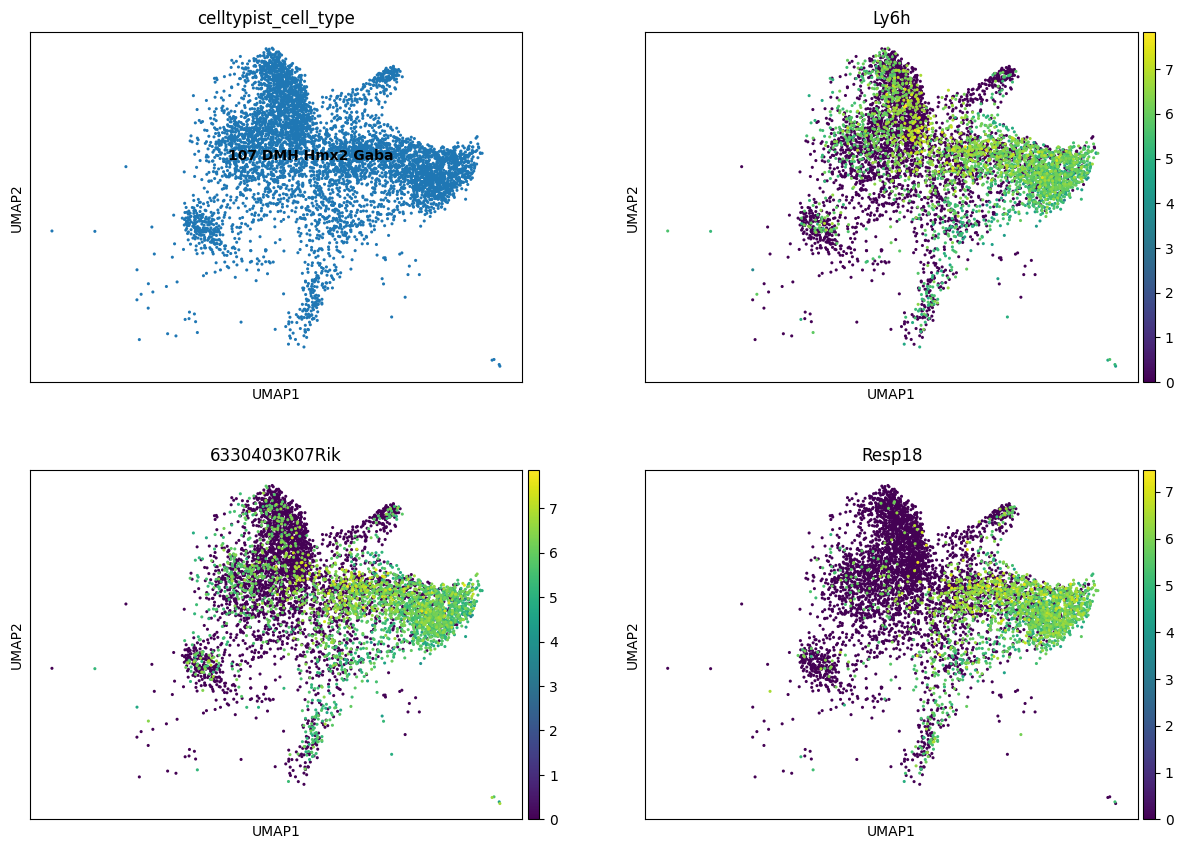

In [93]:
#per cells in a region
#sc.pl.umap(adata[adata.obs['celltypist_cell_type'].isin(regions["Hypothalamus"]), :], color=['celltypist_cell_type', 'Ly6h', '6330403K07Rik', 'Resp18'],
#           ncols=2, legend_loc='on data')

# Per celltypes
ctsplot=["107 DMH Hmx2 Gaba"]
sc.pl.umap(adata[adata.obs['celltypist_cell_type'].isin(ctsplot), :], color=['celltypist_cell_type', 'Ly6h', '6330403K07Rik', 'Resp18'],
           ncols=2, legend_loc='on data')
